# Reconhecimento Facial com Eigenfaces (PCA / SVD)

Projeto final — aplicação de **PCA (Análise de Componentes Principais)** e
**decomposição SVD** para reconhecimento facial simplificado, usando a técnica
clássica de *Eigenfaces* (Turk & Pentland, 1991).

**Dataset:** Olivetti Faces — 40 pessoas, 10 fotos cada (400 imagens), 64×64 pixels
em escala de cinza.

**Roteiro deste notebook:**
1. Carregar os dados
2. Rosto médio e centralização
3. PCA via autovalores de A^T A
4. Visualizar as eigenfaces
5. Variância explicada
6. Reconstrução com rank crescente
7. Erro de reconstrução vs. número de componentes
8. Classificação por vizinho mais próximo
9. Precisão vs. número de componentes
10. Matriz de confusão
11. Comparação com SVD direta (teste de sanidade + estabilidade numérica)
12. Conclusões

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

np.random.seed(42)
plt.rcParams["figure.facecolor"] = "white"

## 1. Carregando os dados

Cada imagem (64x64 pixels) é esticada em um vetor de 4096 numeros. Empilhando as
400 imagens, foi montada a matriz A (4096 x 400), onde cada **coluna** é um rosto.

In [31]:
import numpy as np

caminho_npz = "/content/olivetti_faces.npz"  # ajuste se subiu em outro lugar
dados_npz = np.load(caminho_npz)
imagens = dados_npz["imagens"]
rotulos = dados_npz["rotulos"]

altura, largura = imagens.shape[1], imagens.shape[2]
A = imagens.reshape(imagens.shape[0], -1).T
n_pixels, n_amostras = A.shape
n_pessoas = len(set(rotulos))

print(f"Matriz A: {n_pixels} pixels x {n_amostras} amostras")
print(f"Dimensao original das imagens: {altura}x{largura}")
print(f"Numero de pessoas distintas: {n_pessoas}")

Matriz A: 4096 pixels x 400 amostras
Dimensao original das imagens: 64x64
Numero de pessoas distintas: 40


## 2. Rosto medio e centralizacao

O PCA assume dados centralizados na origem. É calculado o rosto medio (media de
cada pixel ao longo de todas as 400 fotos) e subtrai essa média de cada coluna.

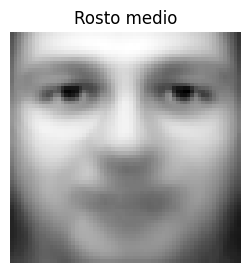

In [32]:
media = A.mean(axis=1)
A_centralizada = A - media[:, None]

plt.figure(figsize=(3, 3))
plt.imshow(media.reshape(altura, largura), cmap="gray")
plt.title("Rosto medio")
plt.axis("off")
plt.show()

## 3. PCA via autovalores de A^T A

Como o numero de pixels (4096) é muito maior que o numero de amostras (400), é mais
eficiente resolver o problema de autovalores na matriz pequena A^T A (400x400) em vez
da matriz grande A A^T (4096x4096), e depois recuperar os autovetores grandes (as
eigenfaces) pela relacao: se A^T A v = lambda v, entao A A^T (A v) = lambda (A v).

Ou seja, se v e autovetor de A^T A, entao A v e autovetor de A A^T associado ao
mesmo autovalor.

In [33]:
def calcular_pca(A, n_componentes=None):
    """PCA via autovalores de A^T A. Retorna (autovetores, autovalores) em ordem decrescente."""
    n_amostras = A.shape[1]
    if n_componentes is None:
        n_componentes = n_amostras

    M = (A.T @ A) / (n_amostras - 1)
    autovalores, autovetores_M = np.linalg.eigh(M)

    ordem = np.argsort(autovalores)[::-1]
    autovalores = autovalores[ordem]
    autovetores_M = autovetores_M[:, ordem]

    autovetores = A @ autovetores_M
    normas = np.linalg.norm(autovetores, axis=0)
    normas[normas == 0] = 1
    autovetores = autovetores / normas

    n_componentes = min(n_componentes, autovetores.shape[1])
    return autovetores[:, :n_componentes], autovalores[:n_componentes]


def projetar(A, media, autovetores):
    """Projeta as colunas de A (dados originais, nao centralizados) no espaco reduzido."""
    A_centralizada = A - media[:, None]
    return autovetores.T @ A_centralizada


def reconstruir(coeficientes, media, autovetores):
    """Reconstroi as imagens originais a partir dos coeficientes projetados."""
    return autovetores @ coeficientes + media[:, None]


def variancia_explicada_acumulada(autovalores):
    autovalores = np.clip(autovalores, a_min=0, a_max=None)
    total = autovalores.sum()
    return np.cumsum(autovalores) / total if total > 0 else np.zeros_like(autovalores)


def n_componentes_para_variancia(autovalores, alvo):
    acumulada = variancia_explicada_acumulada(autovalores)
    indices = np.where(acumulada >= alvo)[0]
    return int(indices[0]) + 1 if len(indices) else len(autovalores)


# calcula todos os componentes possiveis de uma vez. são fatiados depois conforme a necessidade
autovetores_completos, autovalores_completos = calcular_pca(A_centralizada, n_componentes=None)
print(f"Total de componentes calculados: {autovetores_completos.shape[1]}")

Total de componentes calculados: 400


## 4. Visualizando as eigenfaces

Os primeiros componentes principais (eigenfaces) sao as direções de maior variação
entre os rostos. Note que costumam aparecer padrões reconheciveis (contorno de oculos,
iluminacao, formato do rosto). Não são rostos reais, são *direções* no espaco de
rostos.

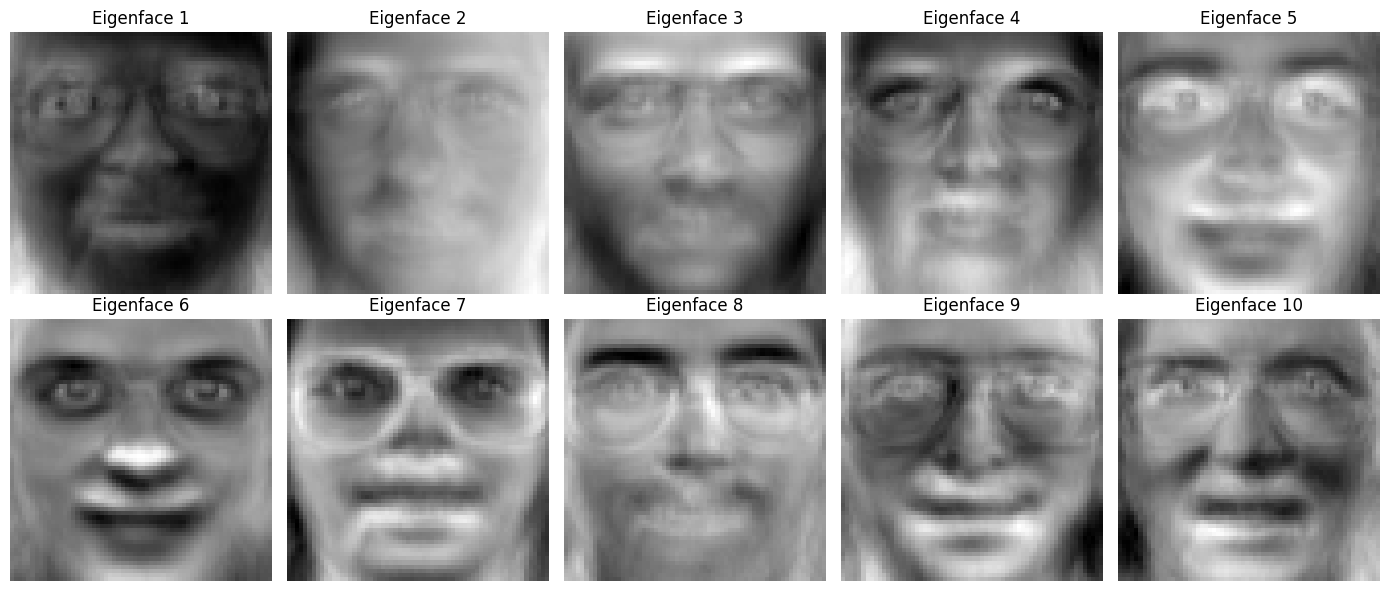

In [34]:
fig, eixos = plt.subplots(2, 5, figsize=(14, 6))
for i, eixo in enumerate(eixos.flat):
    eixo.imshow(autovetores_completos[:, i].reshape(altura, largura), cmap="gray")
    eixo.set_title(f"Eigenface {i+1}")
    eixo.axis("off")
plt.tight_layout()
plt.show()

## 5. Variancia explicada

Quantos componentes são necessários para capturar a maior parte da informação
(variância) dos dados originais?

Componentes necessarios para 90% da variancia: 66
Componentes necessarios para 95% da variancia: 123
Componentes necessarios para 99% da variancia: 260


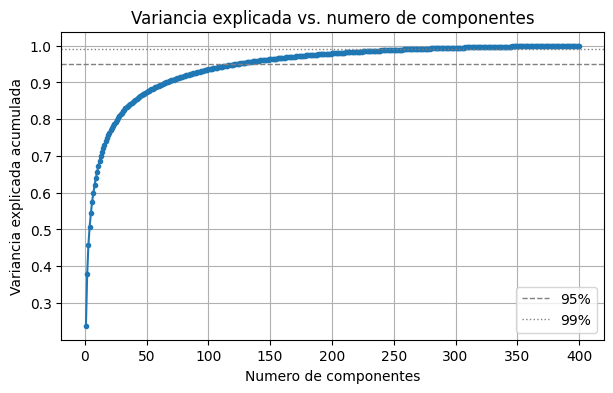

In [35]:
acumulada = variancia_explicada_acumulada(autovalores_completos)

for alvo in [0.90, 0.95, 0.99]:
    k = n_componentes_para_variancia(autovalores_completos, alvo)
    print(f"Componentes necessarios para {alvo:.0%} da variancia: {k}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(acumulada) + 1), acumulada, marker=".")
plt.axhline(0.95, color="gray", linestyle="--", linewidth=1, label="95%")
plt.axhline(0.99, color="gray", linestyle=":", linewidth=1, label="99%")
plt.xlabel("Numero de componentes")
plt.ylabel("Variancia explicada acumulada")
plt.title("Variancia explicada vs. numero de componentes")
plt.legend()
plt.grid(True)
plt.show()

## 6. Reconstrucao com rank crescente

Um rosto pode ser aproximado usando só os primeiros k componentes. Quanto maior k,
mais precisa a reconstrucao e mais memória é necessária para armazená-la.

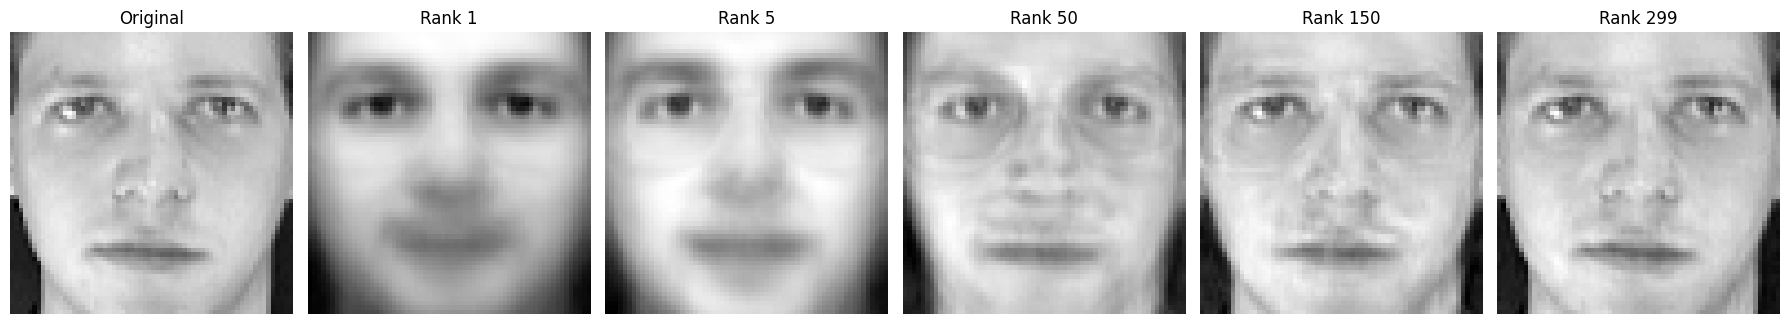

In [52]:
indice_exemplo = 0
ranks = [1, 5, 50, 150, 299]

imagens_reconstruidas = [A[:, indice_exemplo]]
titulos = ["Original"]

for r in ranks:
    coef = projetar(A[:, [indice_exemplo]], media, autovetores_completos[:, :r])
    recon = reconstruir(coef, media, autovetores_completos[:, :r])
    imagens_reconstruidas.append(recon[:, 0])
    titulos.append(f"Rank {r}")

fig, eixos = plt.subplots(1, len(imagens_reconstruidas), figsize=(3 * len(imagens_reconstruidas), 3.3))
for eixo, img, titulo in zip(eixos, imagens_reconstruidas, titulos):
    eixo.imshow(img.reshape(altura, largura), cmap="gray")
    eixo.set_title(titulo)
    eixo.axis("off")
plt.tight_layout()
plt.show()

## 7. Erro de reconstrução vs. número de componentes

O erro (norma de Frobenius entre a matriz original e a reconstruida) deve **cair
progressivamente** conforme é aumentado o número de componentes, ou seja, usando mais informação
nunca piora a melhor aproximação possível.

> **Nota de implementacao:** `projetar()` ja centraliza os dados internamente
> (subtrai a media). Por isso é passado `A` (dados originais) e nao `A_centralizada`
> — passar os dados ja centralizados subtrairia a media duas vezes, distorcendo o
> resultado.

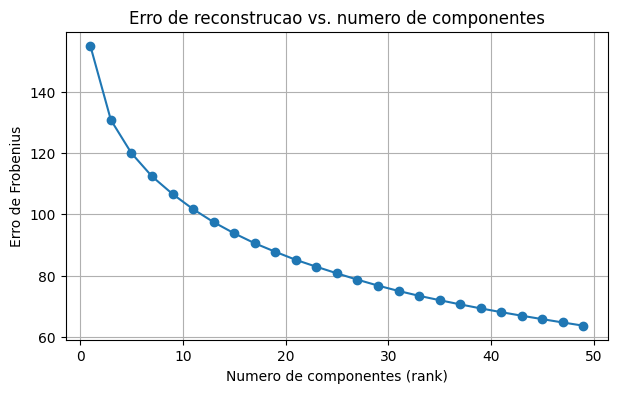

Erro progressivamente decrescente? True


In [56]:
erros = []
lista_ranks_erro = list(range(1, 51, 2))
for r in lista_ranks_erro:
    coef = projetar(A, media, autovetores_completos[:, :r])
    recon = reconstruir(coef, media, autovetores_completos[:, :r])
    erros.append(np.linalg.norm(A - recon, ord="fro"))

plt.figure(figsize=(7, 4))
plt.plot(lista_ranks_erro, erros, marker="o")
plt.xlabel("Numero de componentes (rank)")
plt.ylabel("Erro de Frobenius")
plt.title("Erro de reconstrucao vs. numero de componentes")
plt.grid(True)
plt.show()

decrescente = all(erros[i] >= erros[i+1] - 1e-6 for i in range(len(erros) - 1))
print("Erro progressivamente decrescente?", decrescente)

## 8. Classificação por vizinho mais proximo

São separados os dados em treino (75%) e teste (25%), são calculadas as eigenfaces **usando
só o treino**, e cada rosto de teste é classificado pela distancia euclidiana ao rosto
de treino mais próximo no espaco reduzido.

In [38]:
def classificar_vizinho_mais_proximo(coef_treino, rotulos_treino, coef_teste):
    previsoes = []
    for i in range(coef_teste.shape[1]):
        vetor_teste = coef_teste[:, i]
        distancias = np.linalg.norm(coef_treino - vetor_teste[:, None], axis=0)
        previsoes.append(rotulos_treino[np.argmin(distancias)])
    return np.array(previsoes)


indices = np.arange(n_amostras)
idx_treino, idx_teste = train_test_split(
    indices, test_size=0.25, stratify=rotulos, random_state=42
)

A_treino, A_teste = A[:, idx_treino], A[:, idx_teste]
rotulos_treino, rotulos_teste = rotulos[idx_treino], rotulos[idx_teste]

media_treino = A_treino.mean(axis=1)
A_treino_centralizada = A_treino - media_treino[:, None]

n_max = min(A_treino.shape[1] - 1, 150)
autovetores_treino, _ = calcular_pca(A_treino_centralizada, n_componentes=n_max)

n_componentes_clf = 50
coef_treino = projetar(A_treino, media_treino, autovetores_treino[:, :n_componentes_clf])
coef_teste = projetar(A_teste, media_treino, autovetores_treino[:, :n_componentes_clf])

previsoes = classificar_vizinho_mais_proximo(coef_treino, rotulos_treino, coef_teste)
precisao = np.mean(previsoes == rotulos_teste)
print(f"Precisão com {n_componentes_clf} componentes: {precisao:.2%}")

Precisão com 50 componentes: 94.00%


## 9. Precisão vs. numero de componentes

Quantos componentes é realmente preciso para classificar bem? Vários valores
de rank foram testados e a precisão resultante foi comparada.

Melhor resultado: 95.00% com 75 componentes


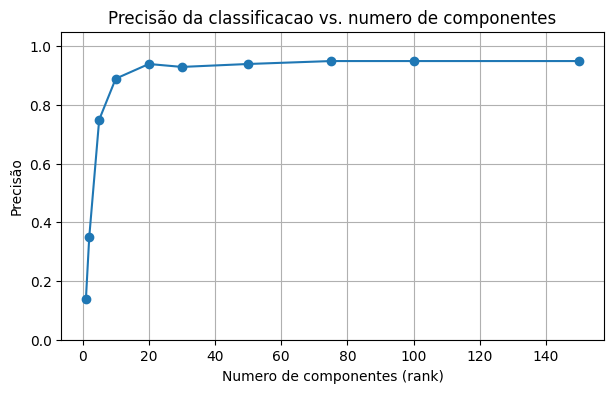

In [39]:
lista_ranks_clf = sorted(set(r for r in [1, 2, 5, 10, 20, 30, 50, 75, 100, n_max] if r <= n_max))
precisoes = []

for r in lista_ranks_clf:
    coef_tr = projetar(A_treino, media_treino, autovetores_treino[:, :r])
    coef_te = projetar(A_teste, media_treino, autovetores_treino[:, :r])
    preds = classificar_vizinho_mais_proximo(coef_tr, rotulos_treino, coef_te)
    precisoes.append(np.mean(preds == rotulos_teste))

melhor_indice = int(np.argmax(precisoes))
print(f"Melhor resultado: {precisoes[melhor_indice]:.2%} com {lista_ranks_clf[melhor_indice]} componentes")

plt.figure(figsize=(7, 4))
plt.plot(lista_ranks_clf, precisoes, marker="o")
plt.xlabel("Numero de componentes (rank)")
plt.ylabel("Precisão")
plt.title("Precisão da classificacao vs. numero de componentes")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

## 10. Matriz de confusão

A precisão agregada não diz quem o modelo confunde com quem. A matriz de confusão
mostra, para cada pessoa real, com qual pessoa o modelo mais errou a previsao.

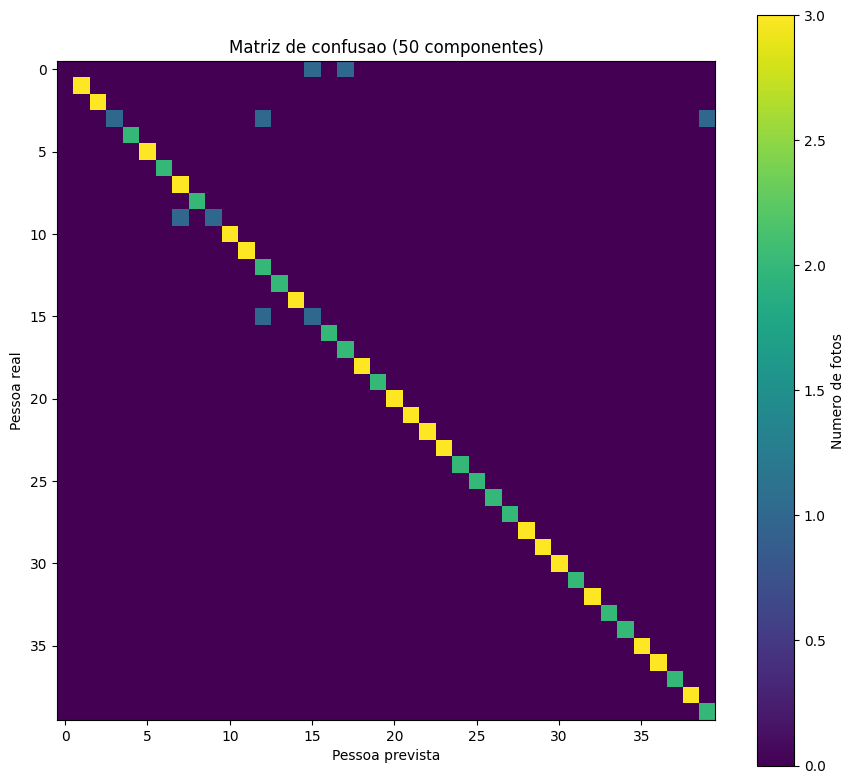

Maiores confusoes (pessoa real -> pessoa prevista : quantidade):
  Pessoa  0 -> Pessoa 15 : 1x
  Pessoa  0 -> Pessoa 17 : 1x
  Pessoa  3 -> Pessoa 12 : 1x
  Pessoa  3 -> Pessoa 39 : 1x
  Pessoa  9 -> Pessoa  7 : 1x
  Pessoa 15 -> Pessoa 12 : 1x


In [40]:
matriz = confusion_matrix(rotulos_teste, previsoes, labels=range(n_pessoas))

fig, eixo = plt.subplots(figsize=(9, 8))
im = eixo.imshow(matriz, cmap="viridis")
eixo.set_xlabel("Pessoa prevista")
eixo.set_ylabel("Pessoa real")
eixo.set_title(f"Matriz de confusao ({n_componentes_clf} componentes)")
plt.colorbar(im, ax=eixo, label="Numero de fotos")
plt.tight_layout()
plt.show()

confusoes = [(i, j, matriz[i, j]) for i in range(n_pessoas) for j in range(n_pessoas)
             if i != j and matriz[i, j] > 0]
confusoes.sort(key=lambda x: x[2], reverse=True)

if confusoes:
    print("Maiores confusoes (pessoa real -> pessoa prevista : quantidade):")
    for real, prevista, contagem in confusoes[:10]:
        print(f"  Pessoa {real:2d} -> Pessoa {prevista:2d} : {contagem}x")
else:
    print("Nenhuma confusao fora da diagonal.")

## 11. Comparacao com SVD direta

Como teste de sanidade, é comparada a rota implementada (autovalores de A^T A) com a
rota alternativa via SVD direta (`np.linalg.svd`). As duas devem concordar, servindo
como verificação cruzada da implementação, e a diferença numerica entre elas (quando
existir) tem explicação teorica: formar A^T A explicitamente eleva o número de
condição da matriz ao quadrado, o que amplia o erro de arredondamento.

In [41]:
n_comparar = 50

t0 = time.perf_counter()
autovetores_pca, autovalores_pca = calcular_pca(A_centralizada, n_componentes=n_comparar)
tempo_pca = time.perf_counter() - t0

t0 = time.perf_counter()
U, valores_singulares, _ = np.linalg.svd(A_centralizada, full_matrices=False)
tempo_svd = time.perf_counter() - t0
autovalores_svd = (valores_singulares ** 2) / (n_amostras - 1)
autovetores_svd = U[:, :n_comparar]
autovalores_svd = autovalores_svd[:n_comparar]

print(f"Tempo via autovalores de A^T A: {tempo_pca*1000:.2f} ms")
print(f"Tempo via SVD direta:            {tempo_svd*1000:.2f} ms")
print()

diferenca_autovalores = np.abs(autovalores_pca - autovalores_svd)
print(f"Maior diferenca absoluta entre autovalores: {diferenca_autovalores.max():.2e}")

# autovetores so sao definidos a menos de sinal -> alinhar antes de comparar
sinais = np.sign(np.sum(autovetores_pca * autovetores_svd, axis=0))
sinais[sinais == 0] = 1
autovetores_svd_alinhados = autovetores_svd * sinais
diferenca_autovetores = np.linalg.norm(autovetores_pca - autovetores_svd_alinhados, axis=0)
print(f"Maior diferenca de norma entre eigenfaces (apos alinhar sinal): {diferenca_autovetores.max():.2e}")
print()

valores_singulares_validos = valores_singulares[valores_singulares > 1e-12]
cond_A = valores_singulares_validos[0] / valores_singulares_validos[-1]
print(f"Numero de condicao de A:          {cond_A:.2e}")
print(f"Numero de condicao de A^T A (A^2): {cond_A**2:.2e}")
print()

diff_max = diferenca_autovetores.max()
if diff_max < 1e-9:
    print("As duas rotas concordam quase exatamente (erro de ponto flutuante puro).")
elif diff_max < 1e-3:
    print("As duas rotas concordam (diferenca pequena, consistente com a amplificacao")
    print("teorica do numero de condicao ao formar A^T A explicitamente).")
else:
    print("Diferenca maior do que o esperado - vale investigar mais a fundo.")

Tempo via autovalores de A^T A: 137.21 ms
Tempo via SVD direta:            612.61 ms

Maior diferenca absoluta entre autovalores: 1.91e-06
Maior diferenca de norma entre eigenfaces (apos alinhar sinal): 6.37e-06

Numero de condicao de A:          4.40e+05
Numero de condicao de A^T A (A^2): 1.93e+11

As duas rotas concordam (diferenca pequena, consistente com a amplificacao
teorica do numero de condicao ao formar A^T A explicitamente).


## 12 Demonstração concreta de uma classificação

As seções anteriores mostram a acurácia agregada (uma média sobre 100 fotos de teste),
mas não mostram explicitamente o mecanismo de decisão caso a caso. Esta seção pega
**uma única foto de teste** e mostra passo a passo:

1. A distância dela (no espaço reduzido de 50 componentes) até **cada uma** das
   fotos de treino;
2. Quais fotos de treino ficaram mais próximas;
3. Qual foi escolhida como previsão (a de menor distância) e se essa escolha
   correspondeu à pessoa correta.

In [ ]:
def testar_uma_classificacao(indice_teste, A_treino, A_teste, media_treino, autovetores,
                              rotulos_treino, rotulos_teste, altura, largura, top_n=5):
    """
    Demonstracao concreta: pega UMA foto de teste especifica, calcula a distancia dela
    ate TODAS as fotos de treino no espaco reduzido, e mostra explicitamente qual foi
    escolhida como "mais proxima" e por que.
    """
    vetor_teste = projetar(A_teste[:, [indice_teste]], media_treino, autovetores)[:, 0]
    coef_treino_local = projetar(A_treino, media_treino, autovetores)

    distancias = np.linalg.norm(coef_treino_local - vetor_teste[:, None], axis=0)
    ordem = np.argsort(distancias)

    pessoa_real = rotulos_teste[indice_teste]
    pessoa_prevista = rotulos_treino[ordem[0]]

    print(f"Foto de teste: indice {indice_teste} | Pessoa REAL: {pessoa_real}")
    print(f"Pessoa PREVISTA (vizinho mais proximo): {pessoa_prevista}")
    print(f"{'ACERTOU' if pessoa_real == pessoa_prevista else 'ERROU'}\n")

    print(f"Top {top_n} fotos de treino mais proximas (indice | pessoa | distancia):")
    for rank, i in enumerate(ordem[:top_n], start=1):
        marca = " <- escolhida" if rank == 1 else ""
        print(f"  {rank}. indice_treino={i:3d} | pessoa={rotulos_treino[i]:2d} | "
              f"distancia={distancias[i]:.4f}{marca}")

    fig, eixos = plt.subplots(1, top_n + 1, figsize=(3 * (top_n + 1), 3.3))

    eixos[0].imshow(A_teste[:, indice_teste].reshape(altura, largura), cmap="gray")
    eixos[0].set_title(f"TESTE\n(pessoa real: {pessoa_real})")
    eixos[0].axis("off")

    for rank, i in enumerate(ordem[:top_n], start=1):
        cor_titulo = "green" if rotulos_treino[i] == pessoa_real else "red"
        eixos[rank].imshow(A_treino[:, i].reshape(altura, largura), cmap="gray")
        destaque = " *" if rank == 1 else ""
        eixos[rank].set_title(f"#{rank}{destaque} pessoa {rotulos_treino[i]}\n"
                               f"dist={distancias[i]:.2f}", color=cor_titulo)
        eixos[rank].axis("off")

    plt.suptitle("Vizinho mais proximo: comparando a foto de teste com o treino inteiro",
                  y=1.05)
    plt.tight_layout()
    plt.show()

    return pessoa_real, pessoa_prevista


# escolha um indice de teste para demonstrar (pode trocar por qualquer valor de 0 a 99)
indice_demo = 0
testar_uma_classificacao(
    indice_demo, A_treino, A_teste, media_treino,
    autovetores_treino[:, :n_componentes_clf],
    rotulos_treino, rotulos_teste, altura, largura, top_n=5
)

## 13. Conclusões

- O PCA/SVD consegue comprimir cada rosto de **4096 pixels** para poucas dezenas de
  numeros mantendo a maior parte da informação relevante para identificação.
- A classificação por vizinho mais próximo no espaço reduzido atinge precisão alta
  (~94% nesse experimento) usando apenas ~50 componentes.
- O erro de reconstrução cai progressivamente com o número de componentes, como a
  teoria de aproximação de posto baixo prevê.
- A rota via autovalores de A^T A e a rota via SVD direta concordam, validando a
  implementação. A pequena diferença numérica observada é consistente com a
  amplificação teporica do número de condição.
- A matriz de confusão mostra que, com componentes suficientes, o modelo não
  apresenta confusões sistemáticas entre pessoas específicas. Os poucos erros
  restantes parecem isolados, não estruturais.